In [1]:
from google.colab import files

uploaded = files.upload()


Saving train.csv to train.csv


In [2]:
import pandas as pd

df = pd.read_csv("train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
!pip install xgboost


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [6]:
# ==========================================
# HOUSE PRICE PREDICTION
# SECTION 1 : DATA PREPROCESSING
# ==========================================

import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv("train.csv")

print("="*60)
print("Dataset Shape:", df.shape)
print("="*60)

# Display first 5 rows
display(df.head())

# Dataset Information
print("\nDataset Information")
print("="*60)
df.info()

# Check Missing Values
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("\nMissing Values")
display(missing)

# Separate Features and Target
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

# Identify Numerical and Categorical Columns
numerical_columns = X.select_dtypes(include=["int64","float64"]).columns

categorical_columns = X.select_dtypes(include=["object"]).columns

print("\nNumber of Numerical Features :", len(numerical_columns))
print("Number of Categorical Features :", len(categorical_columns))

# Import Preprocessing Libraries
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Numerical Pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical Pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Column Transformer
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

print("\nPreprocessing Pipeline Created Successfully.")

# Split Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)

print("\nData Preprocessing Completed Successfully.")

Dataset Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81



Number of Numerical Features : 37
Number of Categorical Features : 43

Preprocessing Pipeline Created Successfully.

Training Data Shape : (1168, 80)
Testing Data Shape : (292, 80)

Data Preprocessing Completed Successfully.


Statistical Summary


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


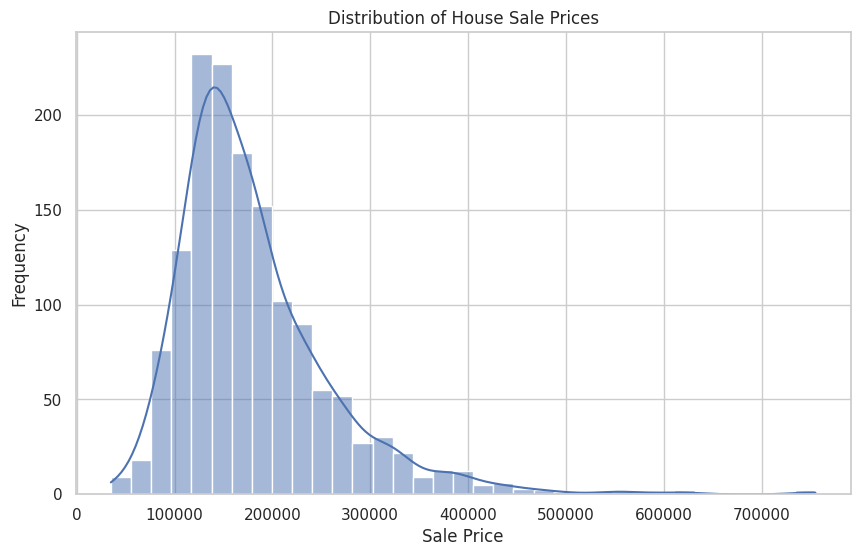

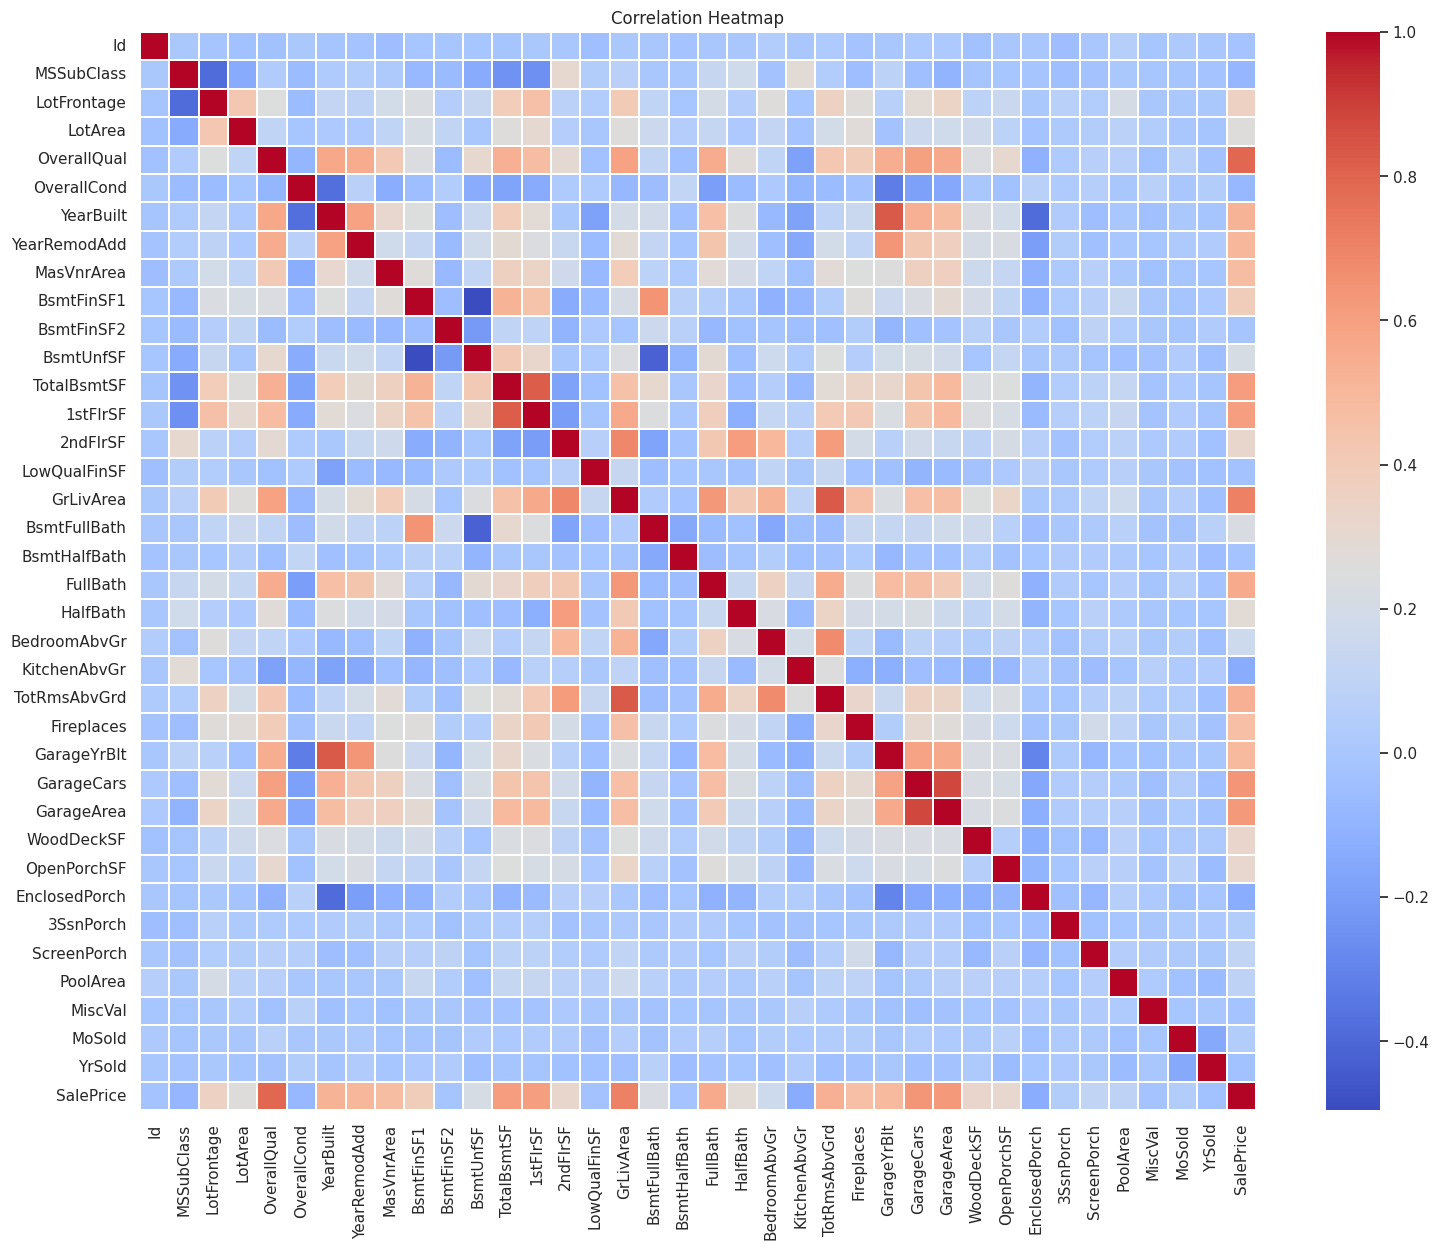

Top Features Correlated with SalePrice


,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


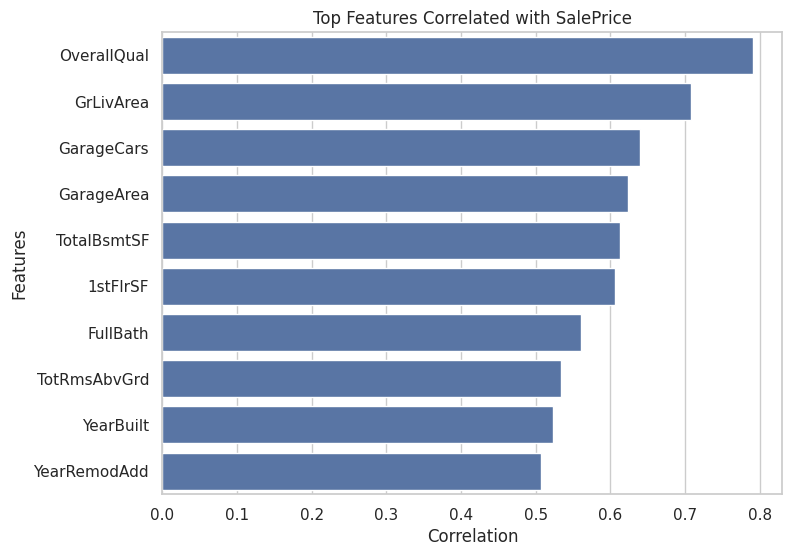

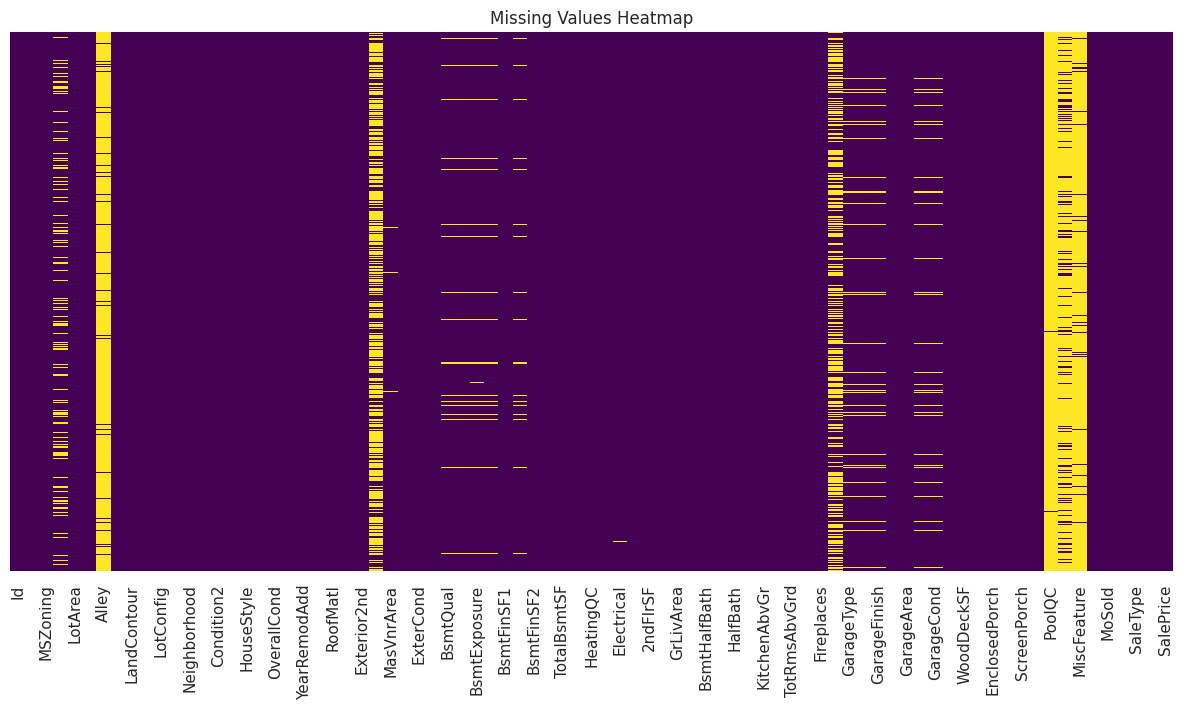

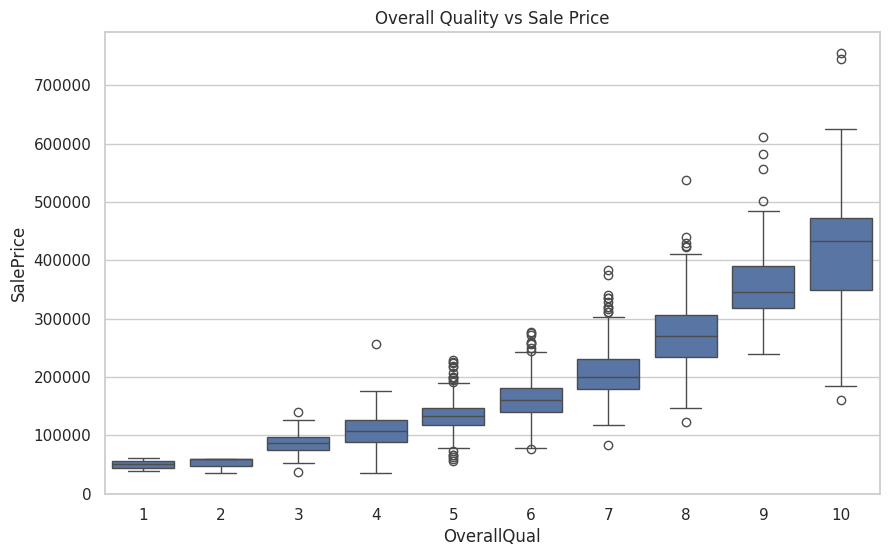

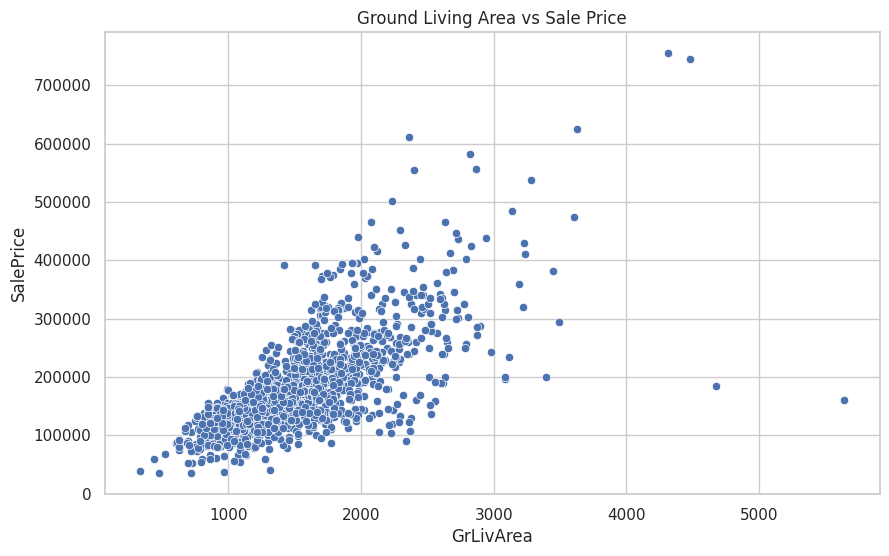

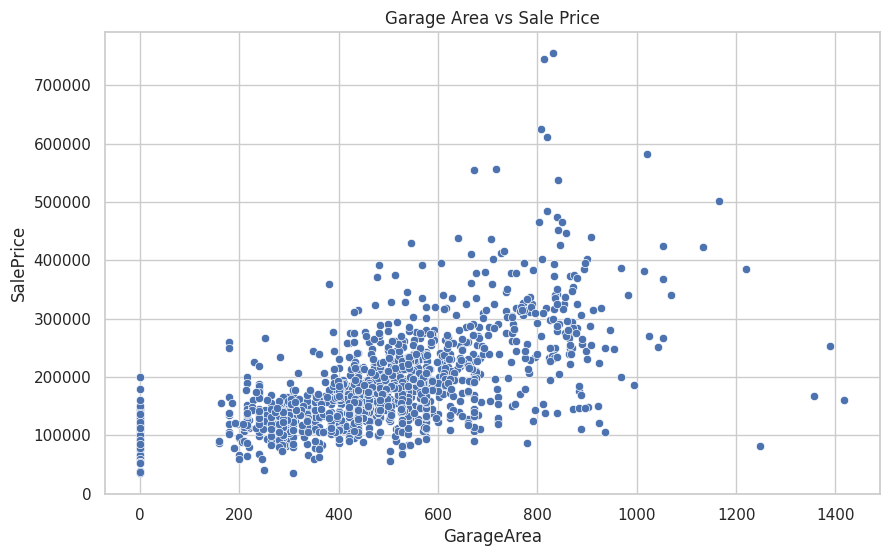

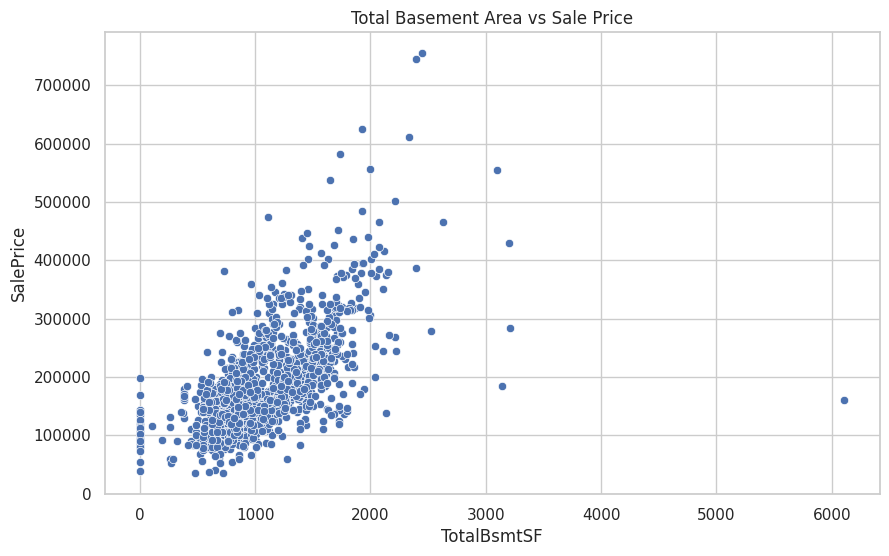

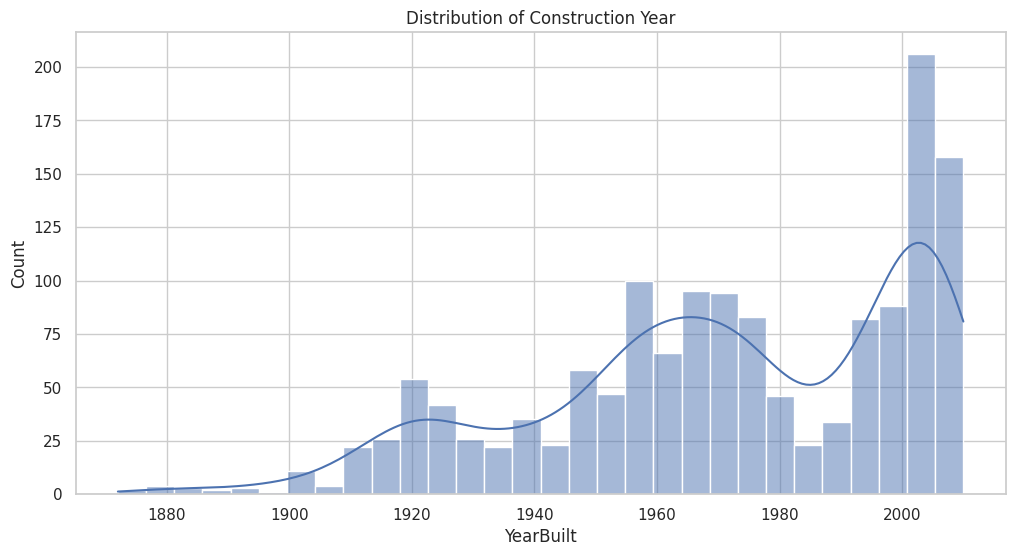

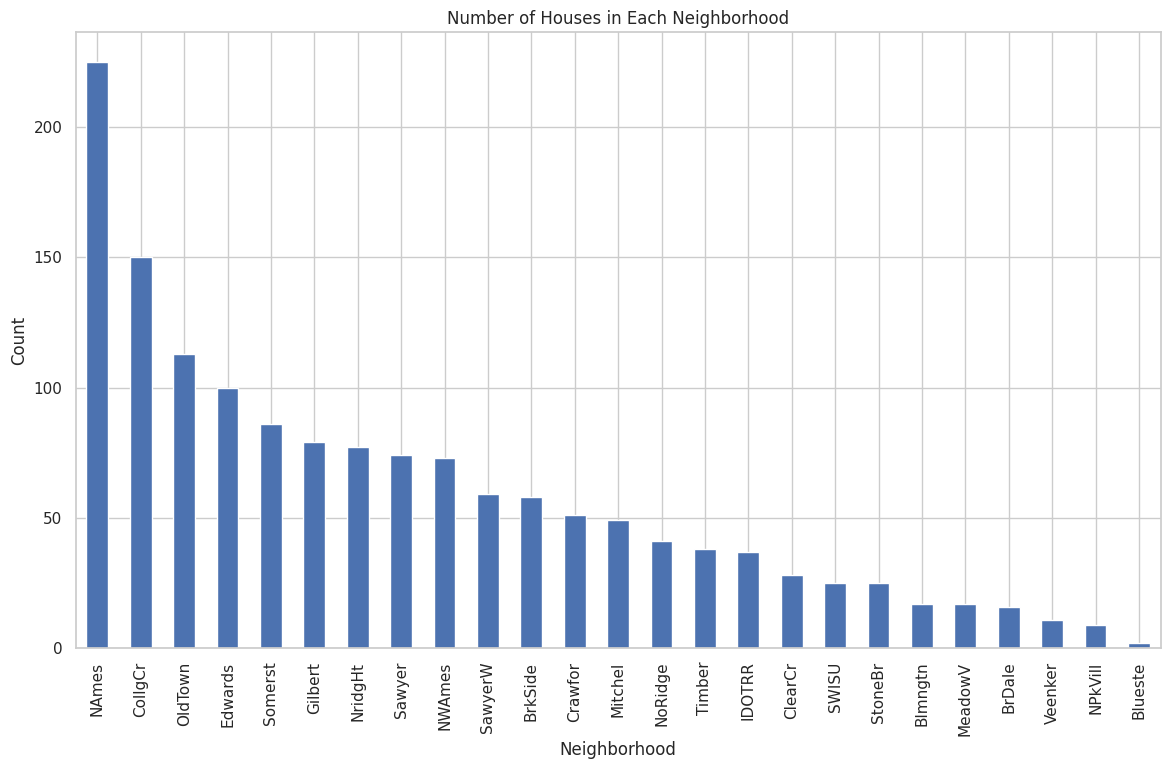

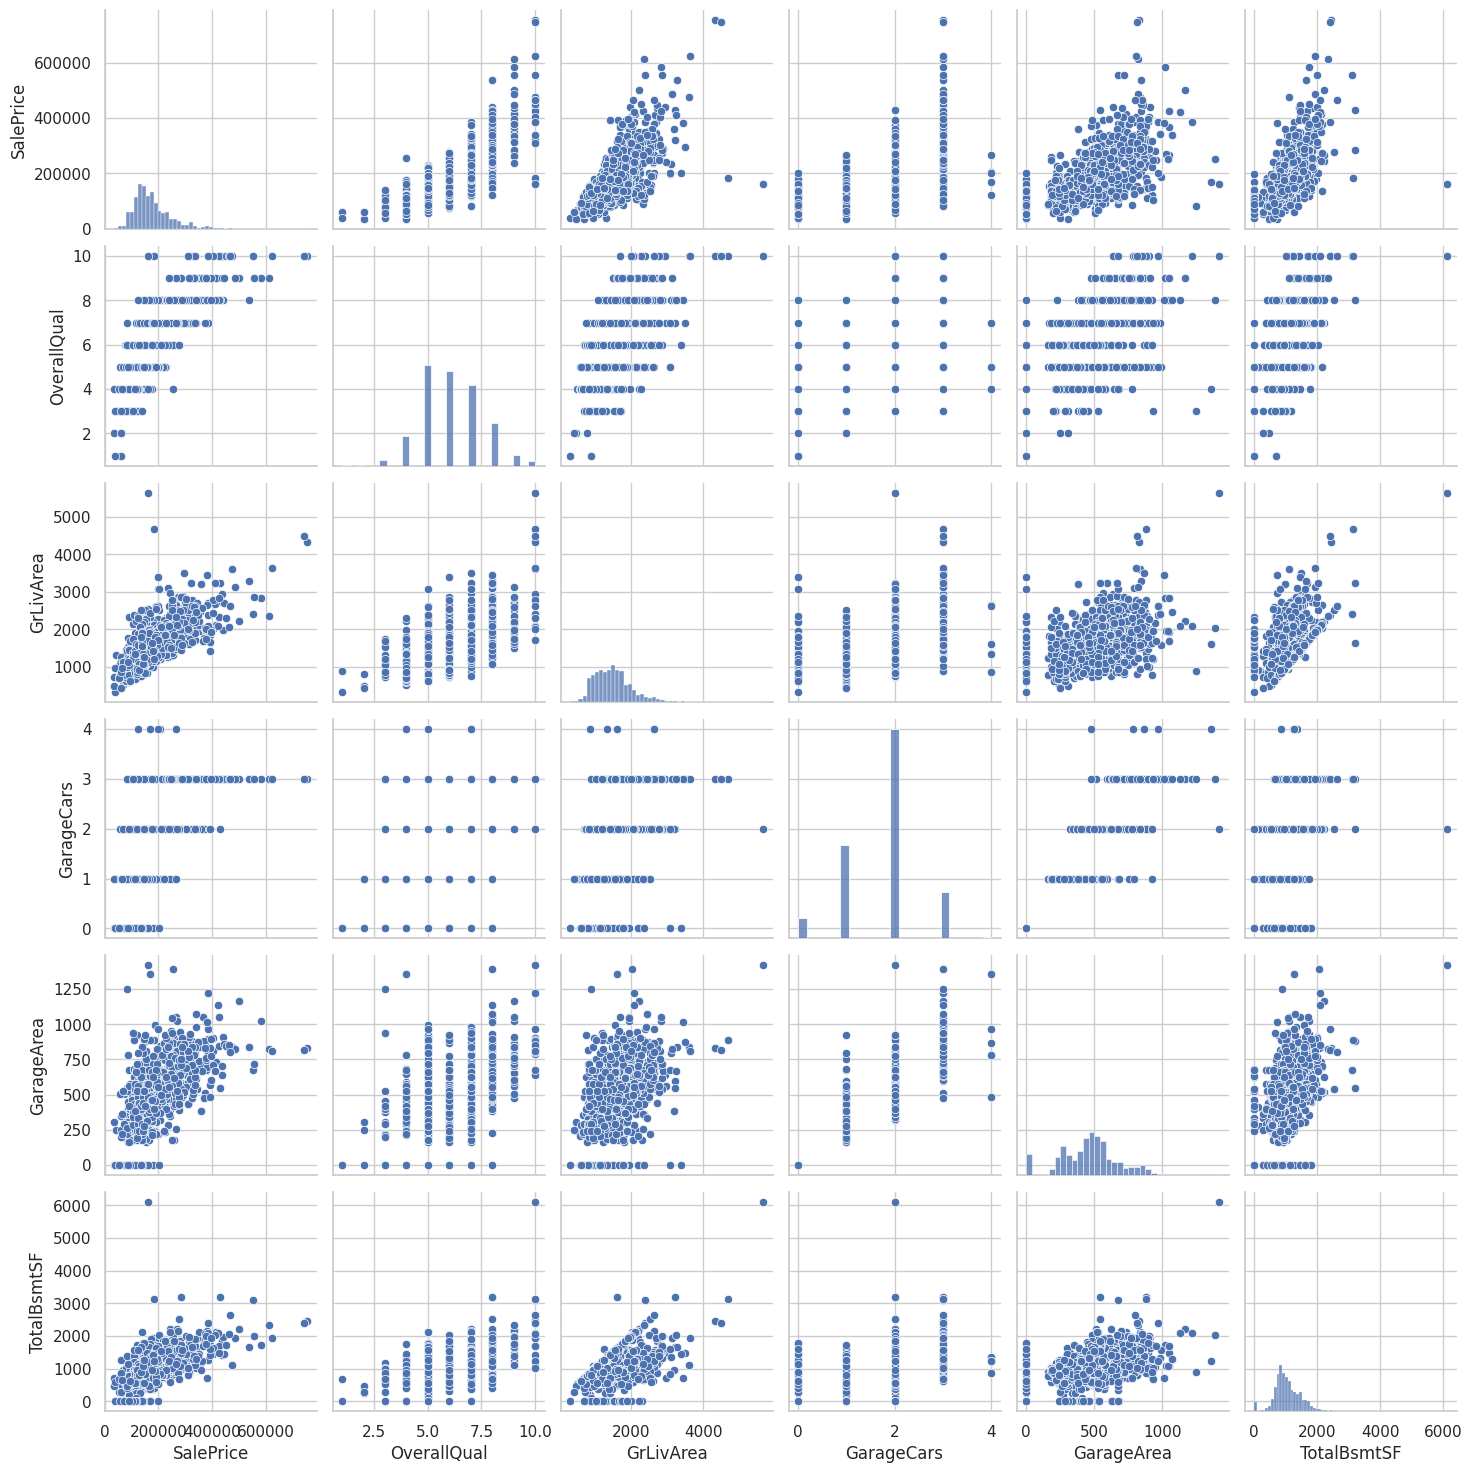

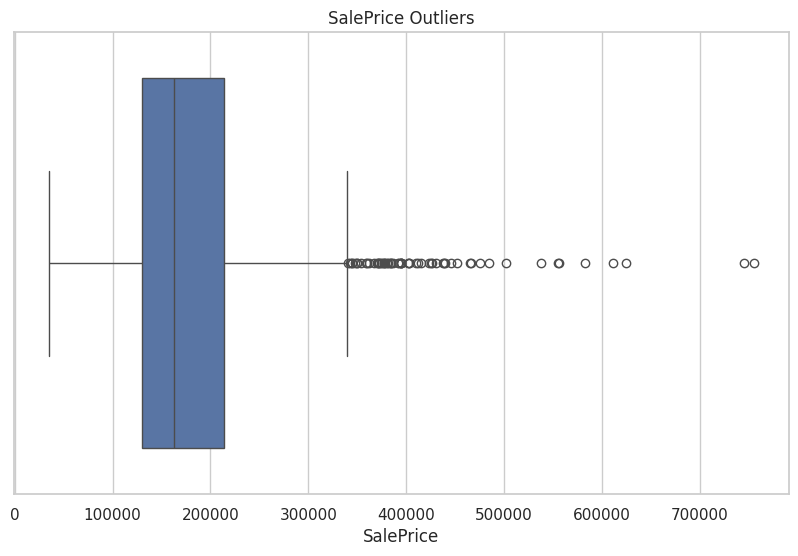

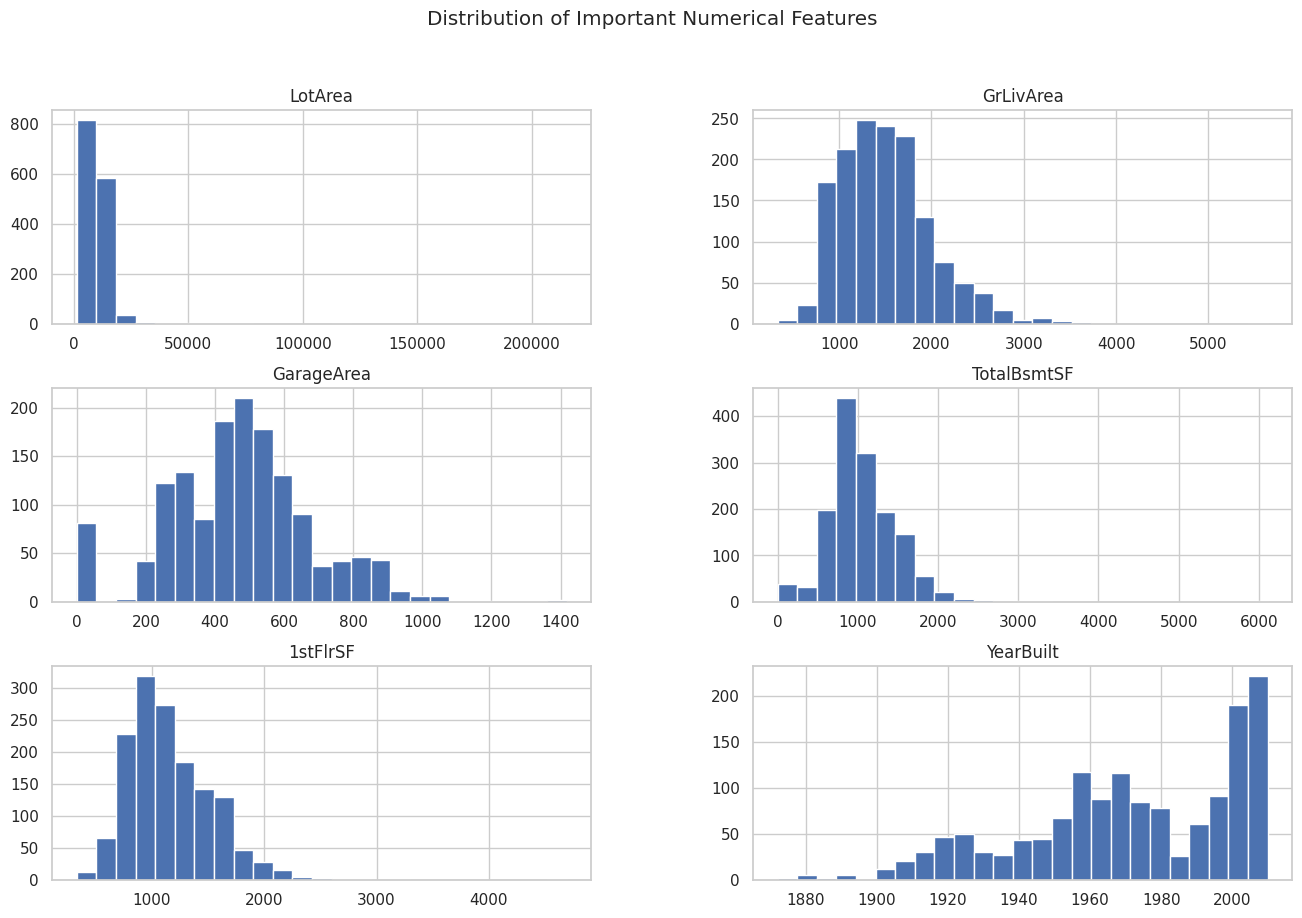

EDA Completed Successfully


In [7]:
# ==========================================================
# HOUSE PRICE PREDICTION
# SECTION 2 : EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# ---------------------------------------------
# Statistical Summary
# ---------------------------------------------
print("="*70)
print("Statistical Summary")
print("="*70)
display(df.describe())

# ---------------------------------------------
# SalePrice Distribution
# ---------------------------------------------
plt.figure(figsize=(10,6))
sns.histplot(df["SalePrice"], bins=35, kde=True)
plt.title("Distribution of House Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

# ---------------------------------------------
# Correlation Heatmap
# ---------------------------------------------
plt.figure(figsize=(18,14))

corr = df.select_dtypes(include=["int64","float64"]).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    linewidths=0.3
)

plt.title("Correlation Heatmap")
plt.show()

# ---------------------------------------------
# Top Correlated Features with SalePrice
# ---------------------------------------------
corr_target = corr["SalePrice"].sort_values(ascending=False)

print("="*70)
print("Top Features Correlated with SalePrice")
print("="*70)

display(corr_target.head(15))

# ---------------------------------------------
# Top Positive Correlation Plot
# ---------------------------------------------
top_features = corr_target.index[1:11]

plt.figure(figsize=(8,6))

sns.barplot(
    x=corr_target.iloc[1:11].values,
    y=top_features
)

plt.title("Top Features Correlated with SalePrice")
plt.xlabel("Correlation")
plt.ylabel("Features")

plt.show()

# ---------------------------------------------
# Missing Value Visualization
# ---------------------------------------------
plt.figure(figsize=(15,7))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

# ---------------------------------------------
# Overall Quality vs SalePrice
# ---------------------------------------------
plt.figure(figsize=(10,6))

sns.boxplot(
    x="OverallQual",
    y="SalePrice",
    data=df
)

plt.title("Overall Quality vs Sale Price")

plt.show()

# ---------------------------------------------
# Ground Living Area vs SalePrice
# ---------------------------------------------
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="GrLivArea",
    y="SalePrice",
    data=df
)

plt.title("Ground Living Area vs Sale Price")

plt.show()

# ---------------------------------------------
# Garage Area vs SalePrice
# ---------------------------------------------
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="GarageArea",
    y="SalePrice",
    data=df
)

plt.title("Garage Area vs Sale Price")

plt.show()

# ---------------------------------------------
# Total Basement Area vs SalePrice
# ---------------------------------------------
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="TotalBsmtSF",
    y="SalePrice",
    data=df
)

plt.title("Total Basement Area vs Sale Price")

plt.show()

# ---------------------------------------------
# Year Built Distribution
# ---------------------------------------------
plt.figure(figsize=(12,6))

sns.histplot(
    df["YearBuilt"],
    bins=30,
    kde=True
)

plt.title("Distribution of Construction Year")

plt.show()

# ---------------------------------------------
# Neighborhood Count
# ---------------------------------------------
plt.figure(figsize=(14,8))

df["Neighborhood"].value_counts().plot(kind="bar")

plt.title("Number of Houses in Each Neighborhood")
plt.ylabel("Count")

plt.show()

# ---------------------------------------------
# Pairplot of Important Features
# ---------------------------------------------
important = [
    "SalePrice",
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF"
]

sns.pairplot(df[important])

plt.show()

# ---------------------------------------------
# Outlier Detection
# ---------------------------------------------
plt.figure(figsize=(10,6))

sns.boxplot(x=df["SalePrice"])

plt.title("SalePrice Outliers")

plt.show()

# ---------------------------------------------
# Numerical Feature Distributions
# ---------------------------------------------
selected_features = [
    "LotArea",
    "GrLivArea",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "YearBuilt"
]

df[selected_features].hist(
    figsize=(16,10),
    bins=25
)

plt.suptitle("Distribution of Important Numerical Features")

plt.show()

print("="*70)
print("EDA Completed Successfully")
print("="*70)

In [8]:
# ==========================================================
# HOUSE PRICE PREDICTION
# SECTION 3 : FEATURE ENGINEERING & MODEL BUILDING
# ==========================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import pandas as pd
import numpy as np

# ----------------------------------------------------------
# Create Pipelines
# ----------------------------------------------------------

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

xgboost_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror"
    ))
])

# ----------------------------------------------------------
# Store Models
# ----------------------------------------------------------

models = {
    "Linear Regression": linear_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgboost_model
}

# ----------------------------------------------------------
# Train Models
# ----------------------------------------------------------

results = []

trained_models = {}

print("="*70)
print("Training Models...")
print("="*70)

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    trained_models[name] = model

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)

    results.append([
        name,
        mae,
        mse,
        rmse,
        r2
    ])

print("\nTraining Completed Successfully!")

# ----------------------------------------------------------
# Model Comparison Table
# ----------------------------------------------------------

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ]
)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

print("\n")
print("="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)

display(results_df)

# ----------------------------------------------------------
# Best Model
# ----------------------------------------------------------

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("\n")
print("="*70)
print("Best Model Selected")
print("="*70)

print(f"Best Model : {best_model_name}")

print("\nBest Model Metrics")

display(results_df.iloc[[0]])

print("\nSection 3 Completed Successfully.")

Training Models...

Training Linear Regression...

Training Random Forest...

Training XGBoost...

Training Completed Successfully!


MODEL PERFORMANCE COMPARISON


,Model,MAE,MSE,RMSE,R2 Score
2,XGBoost,15995.774414,6.862323e+08,26196.035120,0.910534
1,Random Forest,17494.262637,8.111548e+08,28480.779436,0.894248
0,Linear Regression,20485.659297,9.814308e+08,31327.795381,0.872048




Best Model Selected
Best Model : XGBoost

Best Model Metrics


,Model,MAE,MSE,RMSE,R2 Score
2,XGBoost,15995.774414,686232256.0,26196.03512,0.910534



Section 3 Completed Successfully.


FINAL MODEL PERFORMANCE
Best Model        : XGBoost
Mean Absolute Error : 15995.77
Mean Squared Error  : 686232256.00
Root Mean Squared Error : 26196.04
R² Score : 0.9105


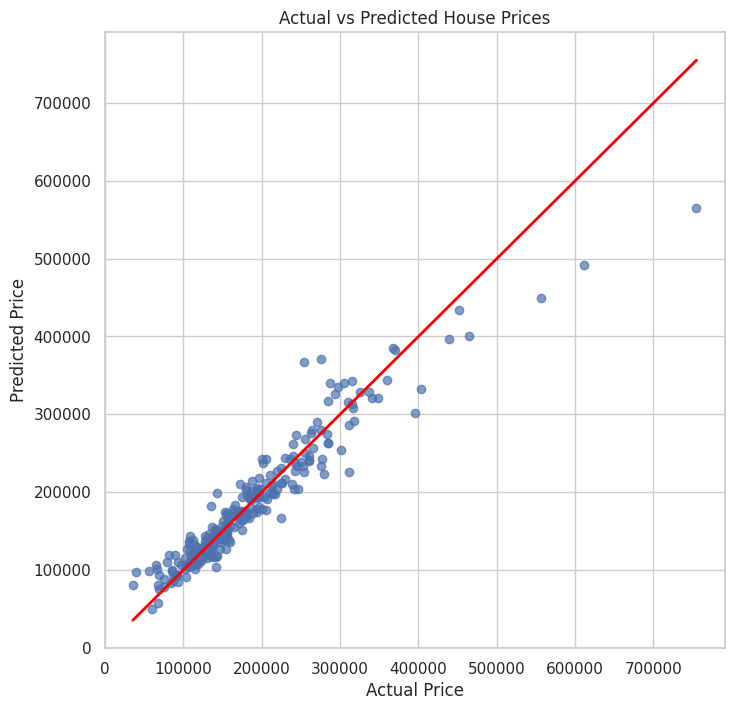

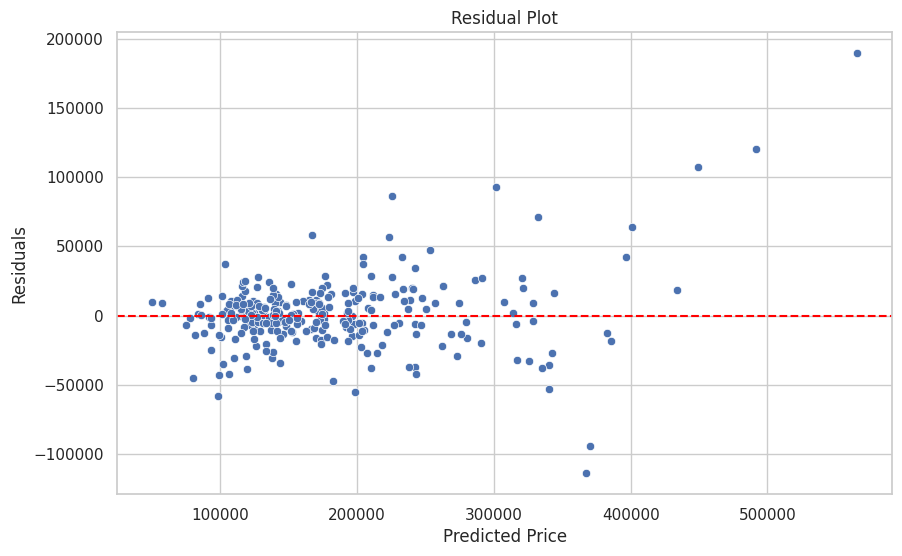

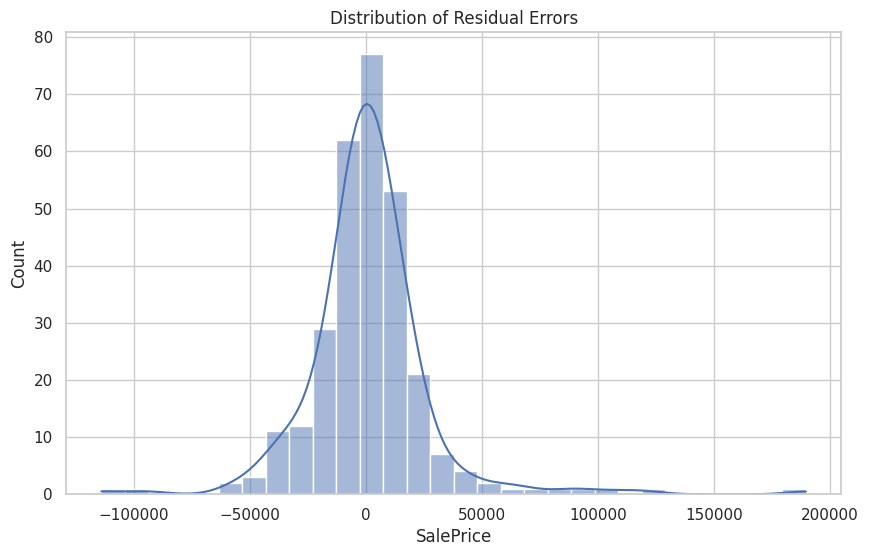


Best model saved successfully!
Evaluation metrics saved successfully!

Sample Predictions


,Actual Price,Predicted Price
0,154500.0,140464.27
1,325000.0,328769.94
2,115000.0,108354.30
3,159000.0,156943.67
4,315500.0,313647.56
5,75500.0,77494.45
6,311500.0,225207.09
7,146000.0,147875.64
8,84500.0,83264.52
9,135500.0,131518.61


SECTION 4 COMPLETED SUCCESSFULLY


In [9]:
# ==========================================================
# HOUSE PRICE PREDICTION
# SECTION 4 : MODEL EVALUATION & MODEL SAVING
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import numpy as np

# ----------------------------------------------------------
# Predictions
# ----------------------------------------------------------

y_pred = best_model.predict(X_test)

# ----------------------------------------------------------
# Final Evaluation Metrics
# ----------------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("="*70)
print("FINAL MODEL PERFORMANCE")
print("="*70)

print(f"Best Model        : {best_model_name}")
print(f"Mean Absolute Error : {mae:.2f}")
print(f"Mean Squared Error  : {mse:.2f}")
print(f"Root Mean Squared Error : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

# ----------------------------------------------------------
# Actual vs Predicted
# ----------------------------------------------------------

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

# ----------------------------------------------------------
# Residual Plot
# ----------------------------------------------------------

residuals = y_test - y_pred

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

# ----------------------------------------------------------
# Residual Distribution
# ----------------------------------------------------------

plt.figure(figsize=(10,6))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Distribution of Residual Errors")

plt.show()

# ----------------------------------------------------------
# Save Model
# ----------------------------------------------------------

os.makedirs("Model", exist_ok=True)

with open("Model/best_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("\nBest model saved successfully!")

# ----------------------------------------------------------
# Save Evaluation Metrics
# ----------------------------------------------------------

metrics = {
    "Best Model": best_model_name,
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r2
}

with open("Model/model_metrics.pkl", "wb") as file:
    pickle.dump(metrics, file)

print("Evaluation metrics saved successfully!")

# ----------------------------------------------------------
# Sample Predictions
# ----------------------------------------------------------

comparison = np.round(
    np.column_stack((y_test.values, y_pred)),
    2
)

comparison_df = pd.DataFrame(
    comparison,
    columns=["Actual Price", "Predicted Price"]
)

print("\nSample Predictions")

display(comparison_df.head(15))

print("="*70)
print("SECTION 4 COMPLETED SUCCESSFULLY")
print("="*70)